#### 로지스틱 회귀로 와인 분류하기

In [2]:
import pandas as pd

In [4]:
wine = pd.read_csv("../Data/wine.csv")
wine.head()

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0


In [6]:
# class의 종류 파악
wine['class'].value_counts()

class
1.0    4898
0.0    1599
Name: count, dtype: int64

> 0: Red Wine, 1: White Wine

In [7]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   pH       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB


In [9]:
wine.shape

(6497, 4)

In [10]:
# 기본 통계량
wine.describe()

,alcohol,sugar,pH,class
count,6497.000000,6497.000000,6497.000000,6497.000000
mean,10.491801,5.443235,3.218501,0.753886
std,1.192712,4.757804,0.160787,0.430779
min,8.000000,0.600000,2.720000,0.000000
25%,9.500000,1.800000,3.110000,1.000000
50%,10.300000,3.000000,3.210000,1.000000
75%,11.300000,8.100000,3.320000,1.000000
max,14.900000,65.800000,4.010000,1.000000


#### Feautre와 Target

In [11]:
data = wine[['alcohol', 'sugar', 'pH']].to_numpy()
target = wine['class'].to_numpy()

In [12]:
data[:5]

array([[9.4 , 1.9 , 3.51],
       [9.8 , 2.6 , 3.2 ],
       [9.8 , 2.3 , 3.26],
       [9.8 , 1.9 , 3.16],
       [9.4 , 1.9 , 3.51]])

In [ ]:
target[:5]

array([0., 0., 0., 0., 0.])

#### Train과 Test

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
train_input, test_input, train_target, test_target = \
    train_test_split(
        data,
        target,
        test_size=0.2,
        random_state=42
    )

In [16]:
print("Train : ", train_input.shape)
print("Test : ", test_input.shape)

Train :  (5197, 3)
Test :  (1300, 3)


#### 로지스틱 회귀이므로 표준화 하기

In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

#### 로지스틱 회귀 모델

In [19]:
from sklearn.linear_model import LogisticRegression

In [20]:
lr = LogisticRegression()
lr.fit(train_scaled, train_target)
print("Train : ", lr.score(train_scaled, train_target))
print("Test : ", lr.score(test_scaled, test_target))

Train :  0.7808350971714451
Test :  0.7776923076923077


In [21]:
# 가중치와 편차 구하기
print(lr.coef_, lr.intercept_)

[[ 0.51268071  1.67335441 -0.68775646]] [1.81773456]


In [ ]:
# class = 0.51268071 * alcohol + 1.67335441 * sugar + -0.68775646 * ph + 1.81773456

AttributeError: 'LogisticRegression' object has no attribute 'feature_names_in_'

----
#### 결정트리(Decision Tree)
: 선형회귀나 KNN처럼 전처리 과정이 필요 없다.

##### Decision Tree를 이용한 모델의 생성

In [24]:
from sklearn.tree import DecisionTreeClassifier

In [25]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(train_input, train_target)
print("Train : ", dt.score(train_input, train_target))
print("Test : ", dt.score(test_input, test_target))


Train :  0.996921300750433
Test :  0.8584615384615385


#### 시각화

In [26]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

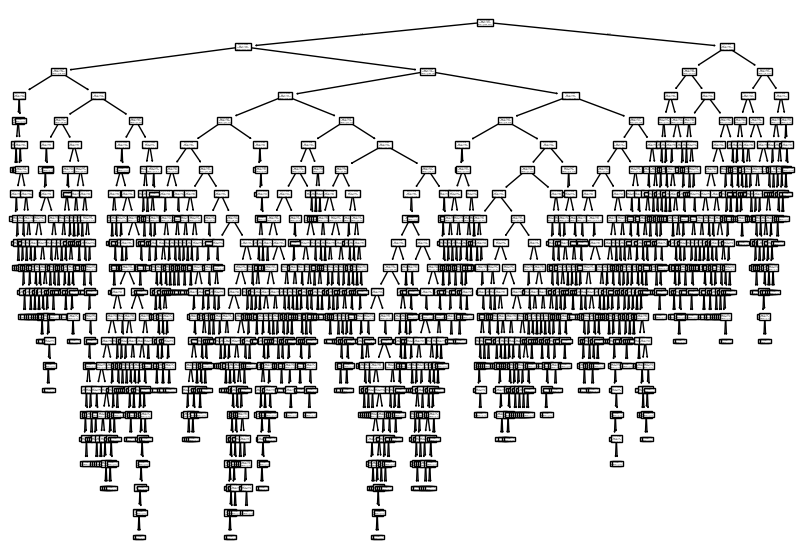

In [27]:
plt.figure(figsize=(10,7))
plot_tree(dt)
plt.show()

> 맨위의 단계를 root node 라고 하고 맨 마지막 단계는 leaf node 라고 한다.     
시간이 너무 많이 걸리고 복잡하다.

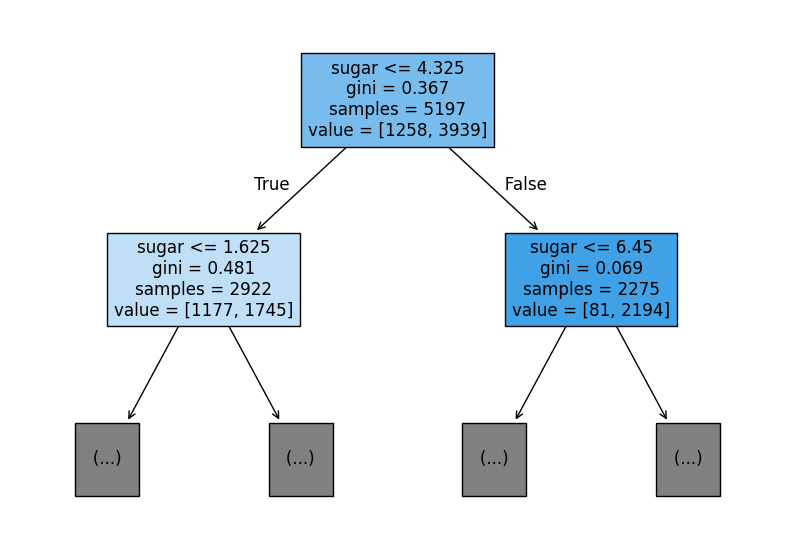

In [28]:
# decision tree의 단계(depth)
plt.figure(figsize=(10,7))
plot_tree(
    dt,
    max_depth=1,
    filled=True,
    feature_names=['alcohol', 'sugar', 'pH']
)
plt.show()

양성(1)일수록 파란색으로 표시된다.    
루트노드에서 sugar <= 4.325이면 왼쪽으로 이동하고 아니면 오른쪽으로 이동한다.    
총 갯수가 5197개 인데 true인 노드는 2922개이고 false인 노드는 2275개 이다.    
지니 불순도(Gini Impurity)가 0이 나올때를 순수노드 라고 한다.    
leaf node가 순수 노드인건 좋으나 이 때 과대적합이 발생한다.     
따라서 적절한 max_depth를 찾는것이 중요하다

#### 가지치기(Tree Pruning)
- max_depth의 parameter 값을 조절.    
- descion tree의 과대적합을 막는다.
- 선형회귀 처럼 규제를 사용할 수 없다.                                                                                                        

In [30]:
dt = DecisionTreeClassifier(
    max_depth=3

)
dt.fit(train_input, train_target)
print("Train : ", dt.score(train_input, train_target))
print("Test : ", dt.score(test_input, test_target))

Train :  0.8454877814123533
Test :  0.8415384615384616


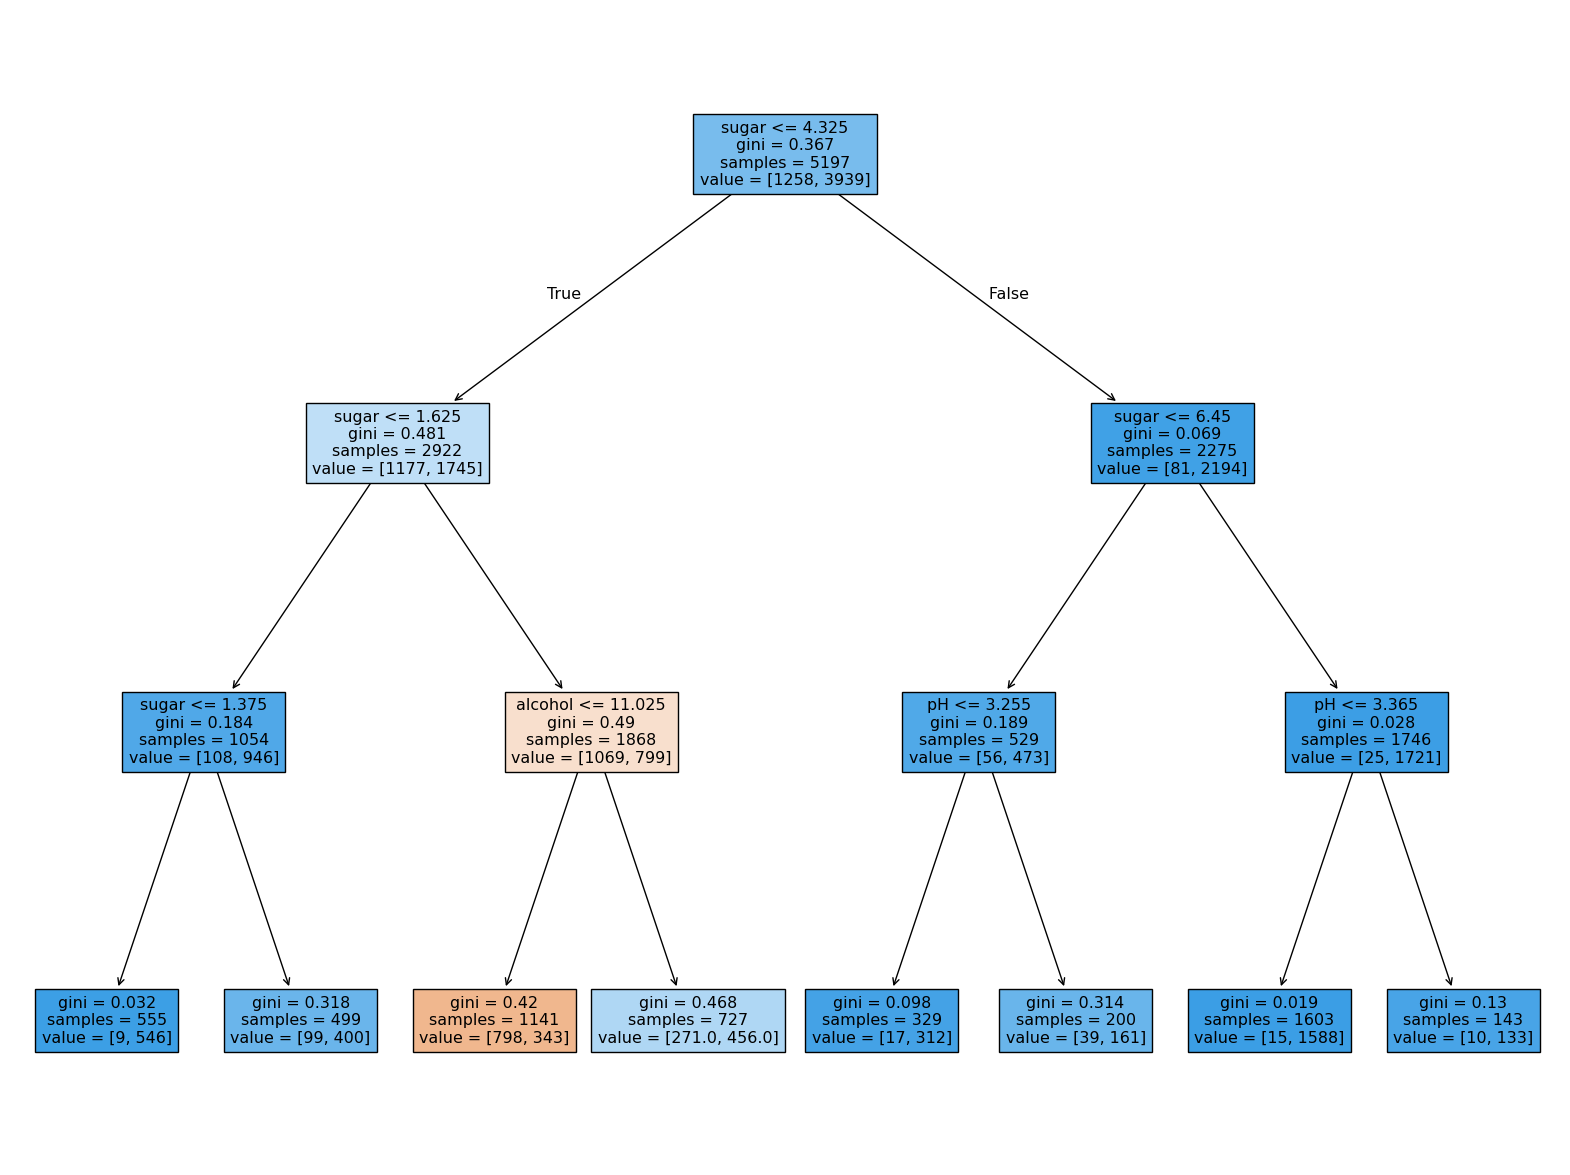

In [31]:
plt.figure(figsize=(20,15))
plot_tree(
    dt,
    filled=True,
    feature_names=['alcohol', 'sugar', 'pH']
)
plt.show()

In [32]:
# 특성 중요도 
dt.feature_importances_

array([0.12345626, 0.86862934, 0.0079144 ])

> alcohol, sugar, pH의 순으로 특성중요도가 출력되묘 이중 sugar가 제일 중요한 요소로 작동된다는 것을 알 수 있다.

#### 최적화 시키기

In [34]:
dt = DecisionTreeClassifier(
    min_impurity_decrease=0.0005 # 노드를 분할하는 기준인 최소 불순도를 0.05%로 결정


)
dt.fit(train_input, train_target)
print("Train : ", dt.score(train_input, train_target))
print("Test : ", dt.score(test_input, test_target))

Train :  0.8874350586877044
Test :  0.8615384615384616


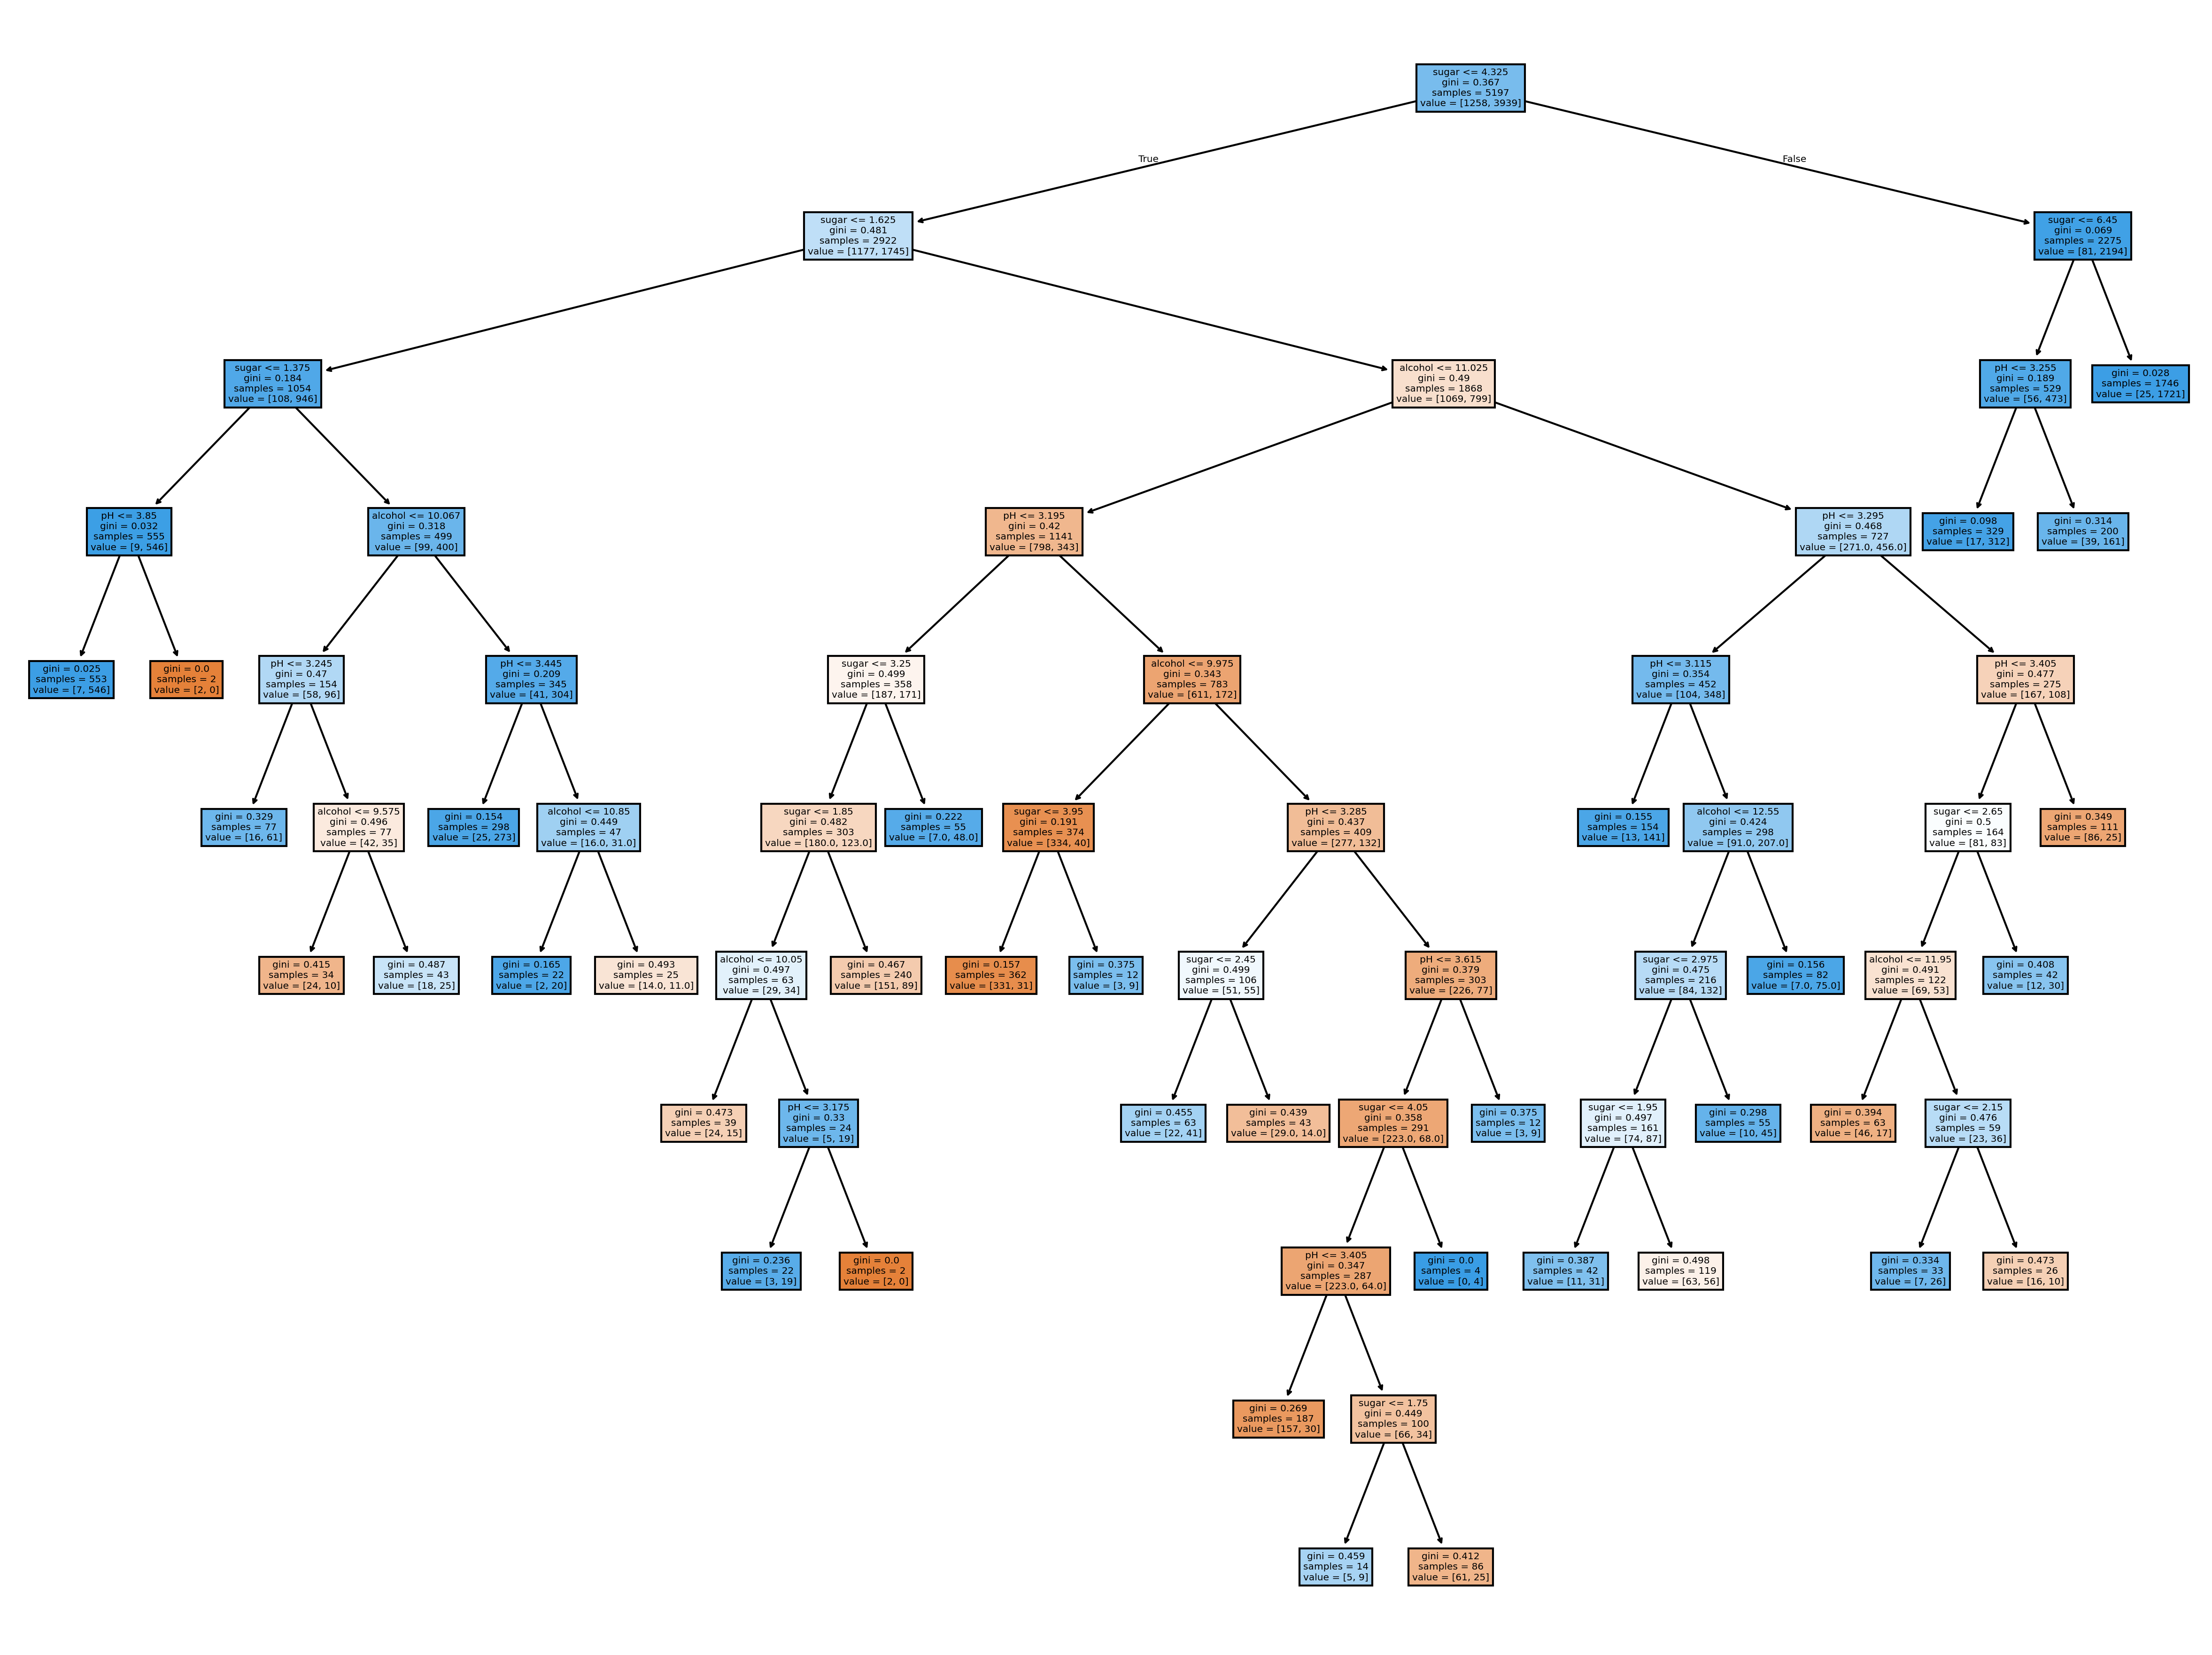

In [36]:
plt.figure(figsize=(20,15), dpi=300)
plot_tree(
    dt,
    filled=True,
    feature_names=['alcohol', 'sugar', 'pH']
)
plt.savefig("../Data/Wine.jpg")
plt.show()